# Result Analysis

This notebook loads the append-only CSV outputs from `results/attack_results/` and `results/algorithm_results/` and summarizes attack reconstruction quality and model performance.

In [1]:
from analysis_utils import (
    load_attack_results,
    load_algorithm_results,
    attack_summary,
    algorithm_summary,
    plot_attack_metric,
    plot_attack_metric_by_round,
    plot_algorithm_crossentropy,
    plot_algorithm_accuracy,
    combine_csvs
)

attack_results_path = "results/attack_results/raw_results.csv"
algorithm_results_path = "results/algorithm_results/raw_results.csv"

attack_rows = load_attack_results(attack_results_path)
algorithm_rows = load_algorithm_results(algorithm_results_path)

attack_rows[:3] if isinstance(attack_rows, list) else attack_rows.head(), algorithm_rows[:3] if isinstance(algorithm_rows, list) else algorithm_rows.head()

([{'index': '0',
   'run': '0',
   'communication_round': '1',
   'client_id': '0',
   'client_label_classes': '[0, 5]',
   'sample_index': '0',
   'algorithm': 'FedAvg',
   'attack': 'DLG',
   'real input value': '[[[0.6274510025978088, 0.6117647290229797, 0.6000000238418579], [0.5411764979362488, 0.5254902243614197, 0.5137255191802979], [0.5568627715110779, 0.5411764979362488, 0.529411792755127], [0.6549019813537598, 0.6392157077789307, 0.6274510025978088], [0.6274510025978088, 0.6117647290229797, 0.6000000238418579], [0.5333333611488342, 0.5254902243614197, 0.5098039507865906], [0.615686297416687, 0.6078431606292725, 0.5960784554481506], [0.6000000238418579, 0.5843137502670288, 0.572549045085907], [0.6196078658103943, 0.5921568870544434, 0.5803921818733215], [0.6274510025978088, 0.5882353186607361, 0.5843137502670288], [0.572549045085907, 0.5254902243614197, 0.5254902243614197], [0.6784313917160034, 0.6352941393852234, 0.6352941393852234], [0.6627451181411743, 0.6196078658103943, 0.

## Summary Tables

In [2]:
attack_summary(attack_rows)

[{'algorithm': 'FedAvg',
  'attack': 'DLG',
  'rows': 150,
  'mean_mse': 0.030805439158963662,
  'min_mse': 0.003538871416822076,
  'max_mse': 0.23298895359039307,
  'mean_psnr': 17.794911314646402,
  'min_psnr': 6.32664680480957,
  'max_psnr': 24.5113525390625,
  'mean_ssim': 0.5442419143269459,
  'min_ssim': 0.02810768596827984,
  'max_ssim': 0.8533077239990234,
  'label_recover': 1.0},
 {'algorithm': 'FedAvg',
  'attack': 'InvertingGradients',
  'rows': 150,
  'mean_mse': 0.0052204227144829925,
  'min_mse': 0.0009544901549816132,
  'max_mse': 0.015206488780677319,
  'mean_psnr': 23.298548329671224,
  'min_psnr': 18.179710388183594,
  'max_psnr': 30.20228385925293,
  'mean_ssim': 0.7803776510556539,
  'min_ssim': 0.5092855095863342,
  'max_ssim': 0.9418830871582031,
  'label_recover': 1.0},
 {'algorithm': 'FedPer(K_p=1)',
  'attack': 'DLG',
  'rows': 150,
  'mean_mse': 0.16910809914271036,
  'min_mse': 0.004017965868115425,
  'max_mse': 0.396151065826416,
  'mean_psnr': 9.24123312314

In [3]:
algorithm_summary(algorithm_rows)

[{'algorithm': 'FedAvg',
  'rows': 300,
  'mean_crossentropy': 2.312674423853556,
  'min_crossentropy': 2.153198719024658,
  'max_crossentropy': 2.485989809036255,
  'accuracy': 0.1},
 {'algorithm': 'FedPer(K_p=1)',
  'rows': 300,
  'mean_crossentropy': 1.3059355797370276,
  'min_crossentropy': 0.18711215257644653,
  'max_crossentropy': 2.4596779346466064,
  'accuracy': 0.5},
 {'algorithm': 'FedPer(K_p=2)',
  'rows': 300,
  'mean_crossentropy': 1.4203820968667666,
  'min_crossentropy': 0.15146134793758392,
  'max_crossentropy': 2.7170777320861816,
  'accuracy': 0.5},
 {'algorithm': 'FedPer(K_p=3)',
  'rows': 300,
  'mean_crossentropy': 1.4232015458742777,
  'min_crossentropy': 0.15042777359485626,
  'max_crossentropy': 2.722386598587036,
  'accuracy': 0.5},
 {'algorithm': 'FedPer(K_p=4)',
  'rows': 300,
  'mean_crossentropy': 1.4235813294847806,
  'min_crossentropy': 0.15023842453956604,
  'max_crossentropy': 2.723182201385498,
  'accuracy': 0.5},
 {'algorithm': 'FedPer(K_p=5)',
  'row

## Attack Comparisons

<Axes: title={'center': 'Mean input mse by algorithm and attack'}, xlabel='Algorithm', ylabel='input mse'>

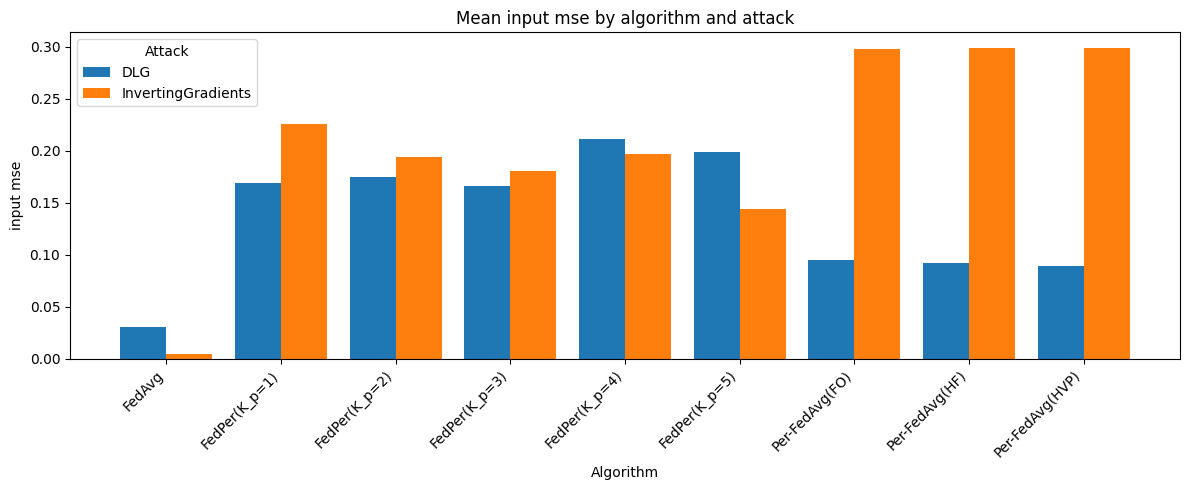

In [4]:
plot_attack_metric(attack_rows, "input mse")

<Axes: title={'center': 'Mean input psnr by algorithm and attack'}, xlabel='Algorithm', ylabel='input psnr'>

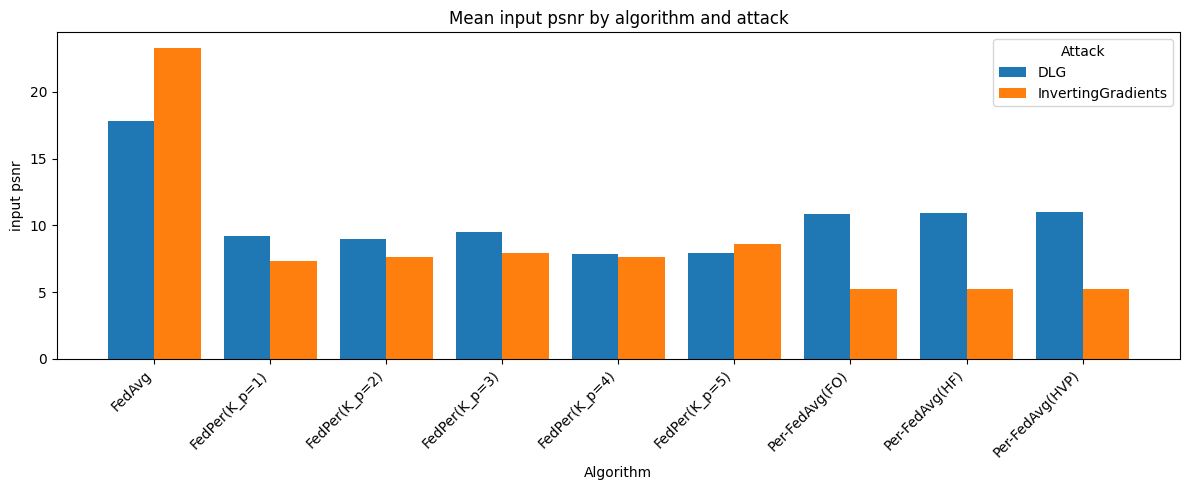

In [5]:
plot_attack_metric(attack_rows, "input psnr")

<Axes: title={'center': 'Mean input ssim by algorithm and attack'}, xlabel='Algorithm', ylabel='input ssim'>

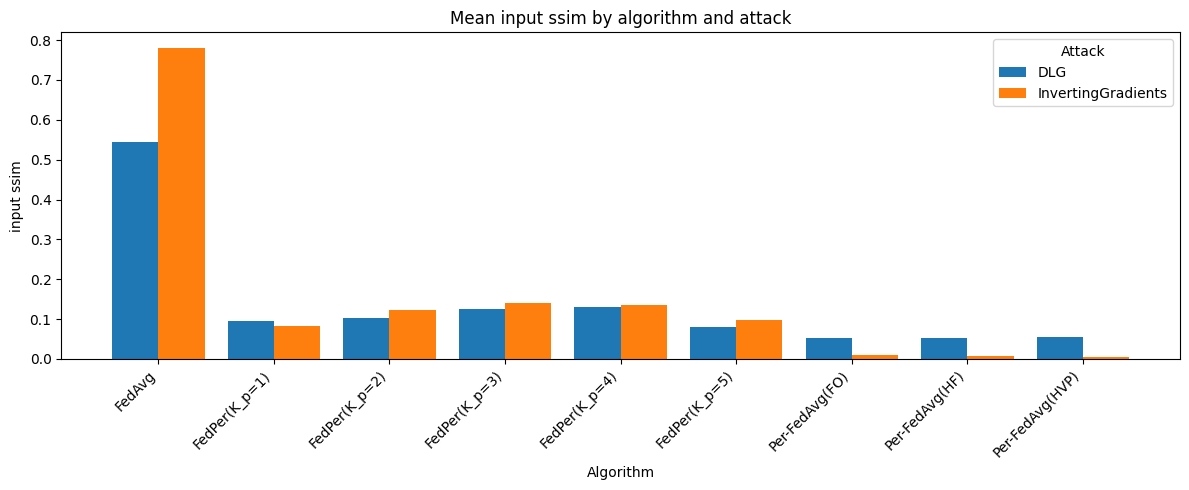

In [6]:
plot_attack_metric(attack_rows, "input ssim")

<Axes: title={'center': 'Label recovery by algorithm and attack'}, xlabel='Algorithm', ylabel='label_recover'>

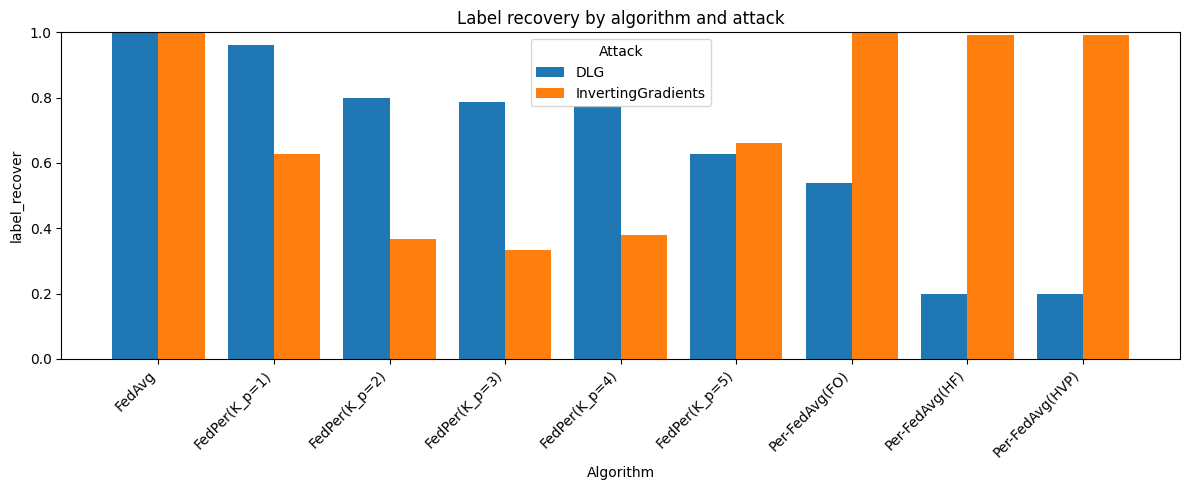

In [7]:
plot_attack_metric(attack_rows, "label_recover", title="Label recovery by algorithm and attack")

## Model Performance

<Axes: title={'center': 'Mean output crossentropy by algorithm'}, xlabel='Algorithm', ylabel='Output crossentropy'>

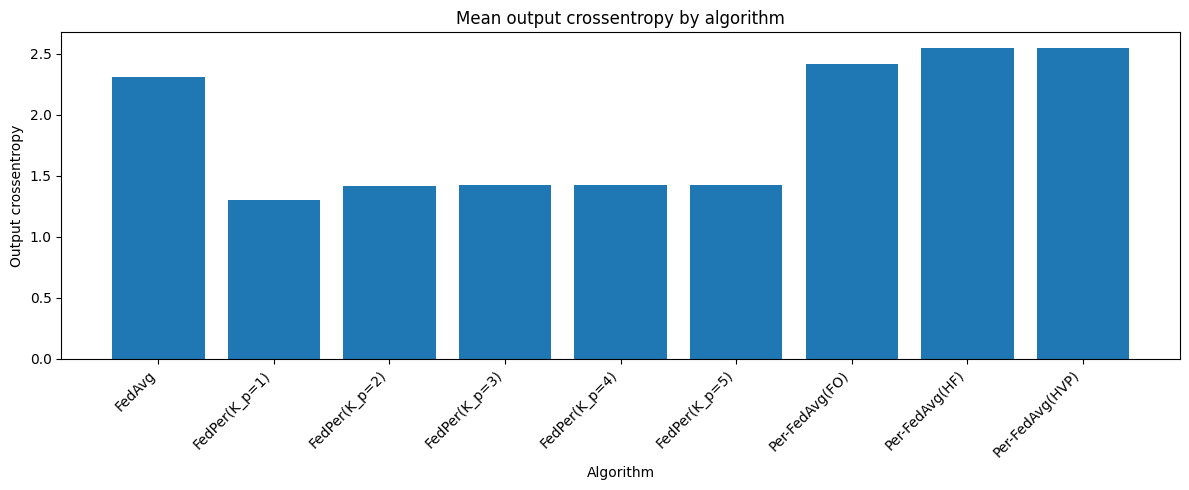

In [8]:
plot_algorithm_crossentropy(algorithm_rows)

<Axes: title={'center': 'Prediction accuracy by algorithm'}, xlabel='Algorithm', ylabel='Accuracy'>

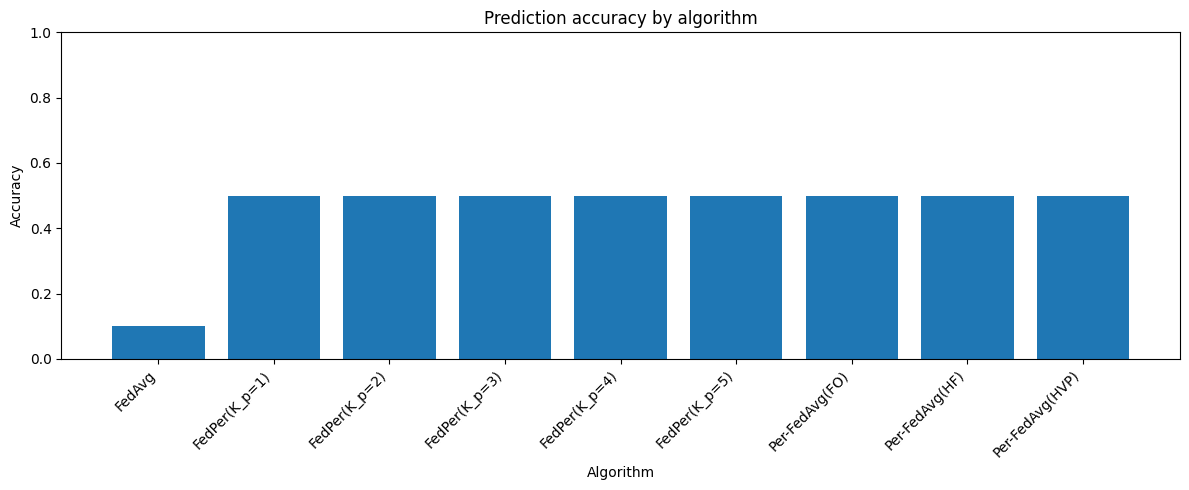

In [9]:
plot_algorithm_accuracy(algorithm_rows)